In [1]:
# Importar librerías 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_bank_marketing=pd.read_csv("C:/Users/patri/OneDrive/Documentos/Proyecto-EDA/data/processed/bank_marketing.csv") 

In [4]:
# Copia de trabajo
data = df_bank_marketing.copy()

print("Dataset cargado correctamente")
print(f"Filas: {data.shape[0]}")
print(f"Columnas: {data.shape[1]}")

Dataset cargado correctamente
Filas: 42752
Columnas: 41


In [5]:
# Seleccionar variables para el modelo
features = [
    "age",
    "duration",
    "campaign",
    "previous",
    "euribor3m",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx"
]

X = data[features]
y = data["y"]

In [6]:
# Separar datos de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Escalar variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Crear y entrenar al modelo
model = LogisticRegression(class_weight="balanced", max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [25]:
# Hacer prediccionaes
y_pred = model.predict(X_test_scaled)

In [27]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# el modelo acierta el 90% de las predicciones

Accuracy: 0.8417728920594083


In [28]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.84      0.90      7574
           1       0.41      0.85      0.55       977

    accuracy                           0.84      8551
   macro avg       0.69      0.85      0.73      8551
weighted avg       0.91      0.84      0.86      8551



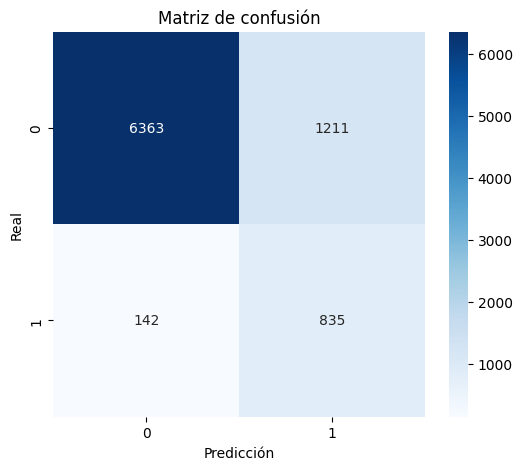

In [29]:
# Matriz de confusión 
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")

plt.show()

- 6363: clientes que no contrataron y el modelo acertó

- 835: clientes que sí contrataron y el modelo acertó

- 1211: clientes que no contrataron pero el modelo pensó que sí

- 142: clientes que sí contrataron pero el modelo predijo que no

In [32]:
clientes_predichos = sum(y_pred)
total_clientes = len(y_pred)

print("Clientes que el modelo predice que contratarán:", clientes_predichos)
print("Total clientes analizados:", total_clientes)

Clientes que el modelo predice que contratarán: 2046
Total clientes analizados: 8551


In [ ]:
tasa_contratacion = clientes_predichos / total_clientes
print("Tasa estimada de contratación:", tasa_contratacion)

# Aproximadamente el 24% de clientes podrían contratar.

Tasa estimada de contratación: 0.2392702607882119


In [39]:
# Supongamos que en 2015 el banco contacta a 10.000 clientes
clientes_estimados = (10000 * tasa_contratacion).round()
print("Clientes estimados que contratarían:", clientes_estimados)

Clientes estimados que contratarían: 2393.0
